## Importy a načtení dat

In [1]:
!pip install ogb --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 kB 994.8 kB/s eta 0:00:00


In [2]:
import networkx as nx
import networkx.algorithms.community as nx_comm
import csv
import numpy as np

import matplotlib.pyplot as plt

import timeit

In [3]:
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
from ogb.nodeproppred import NodePropPredDataset
import numpy as np
import torch

In [4]:
import torch

# Save original torch.load function
_torch_load_func = torch.load

# Define a wrapper that forces weights_only=False
def custom_torch_load(*args, **kwargs):
    kwargs['weights_only'] = False
    return _torch_load_func(*args, **kwargs)

# Monkey-patch torch.load to use our custom wrapper
torch.load = custom_torch_load

# Initialize the dataset (NodePropPredDataset is imported in a previous cell)
dataset = NodePropPredDataset(name='ogbn-arxiv')
graph, y = dataset[0]

Downloaded 0.08 GB: 100%|██████████| 81/81 [00:15<00:00,  5.35it/s]


Extracting dataset/arxiv.zip
Loading necessary files...
This might take a while.
Processing graphs...


100%|██████████| 1/1 [00:00<00:00, 9845.78it/s]

Saving...


In [5]:
graph

{'edge_index': array([[104447,  15858, 107156, ...,  45118,  45118,  45118],
        [ 13091,  47283,  69161, ..., 162473, 162537,  72717]]),
 'edge_feat': None,
 'node_feat': array([[-0.057943, -0.05253 , -0.072603, ...,  0.173364, -0.172796,
         -0.140059],
        [-0.1245  , -0.070665, -0.325202, ...,  0.068524, -0.372111,
         -0.301036],
        [-0.080242, -0.023328, -0.183787, ...,  0.109919,  0.117589,
         -0.139883],
        ...,
        [-0.22053 , -0.036568, -0.402199, ...,  0.11336 , -0.161393,
         -0.145171],
        [-0.138236,  0.040885, -0.251811, ..., -0.08929 , -0.041253,
         -0.376132],
        [-0.029875,  0.268417, -0.161124, ...,  0.120807,  0.077647,
         -0.091018]], dtype=float32),
 'node_year': array([[2013],
        [2015],
        [2014],
        ...,
        [2020],
        [2020],
        [2020]]),
 'num_nodes': 169343}

In [6]:
base_network_path = "./Base.gexf"
labels_file = "../ogbn-arxiv/raw/node-label.csv"
years_file = "../ogbn-arxiv/raw/node_year.csv"
features_file = "../ogbn-arxiv/raw/node_year.csv"

In [7]:
# with open(labels_file, "r") as file:
#     labels_content = np.array(list(csv.reader(file)), dtype=np.int8)

# with open(years_file, "r") as file:
#     years_content = np.array(list(csv.reader(file)), dtype=np.int16)
years_content = graph["node_year"]

## Rychlá analýza dat

In [9]:
label_counts = np.unique_counts(y)
years_counts = np.unique_counts(years_content)

In [10]:
label_counts

UniqueCountsResult(values=array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39]), counts=array([  565,   687,  4839,  2080,  5862,  4958,  1618,   589,  6232,
        2820,  7869,   750,    29,  2358,   597,   403, 27321,   515,
         749,  2877,  2076,   393,  1903,  2834, 22187,  1257,  4605,
        4801, 21406,   416, 11814,  2828,   411,  1271,  7867,   127,
        3524,  2369,  1507,  2029]))

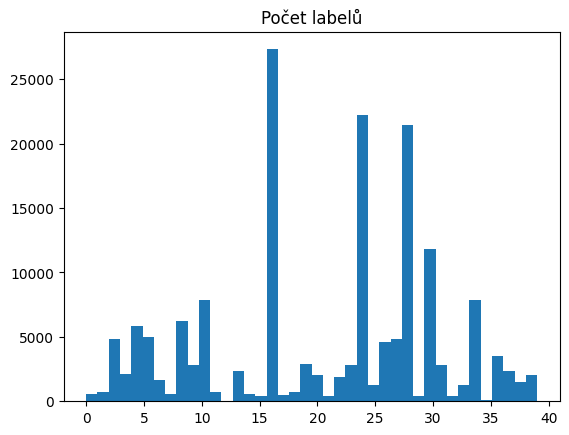

In [11]:
plt.title("Počet labelů")
plt.hist(y, bins=40)
plt.show()

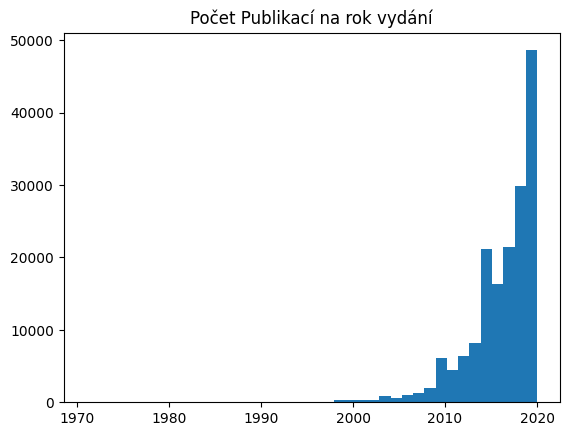

In [13]:
plt.title("Počet Publikací na rok vydání")
plt.hist(years_content, bins=40)
plt.show()

## Detekce komunit

### Louvain

In [ ]:
# G: nx.Graph = nx.read_gexf(base_network_path) #This is my pre-prepared gephi file on which I've run a couple of algorithms on previously.
edges = [(u, v) for u, v in zip(graph["edge_index"][0], graph["edge_index"][1])]
G = nx.Graph(edges)
communities_louvain = nx_comm.louvain_communities(G, seed=42)

In [ ]:
len(communities_louvain)

159

Bylo nalezeno 159 komunit, což je mnohem více, než kolik je v datech tříd (40).

In [ ]:
# Vložení ground truth do souboru
nx.set_node_attributes(G, {node: {"ground_truth": y[int(node)][0]} for node in G.nodes})

In [ ]:
# Vložení idx komunity nalezené pomocí funkce
for idx, community in enumerate(communities_louvain):
    for node in community:
        nx.set_node_attributes(G, {node: {"louvain": idx}})

In [ ]:
print(G.nodes["0"]["ground_truth"], G.nodes["0"]["louvain"])

4 120


Nalezené komunity nebudou přesně reflektovat ground_truth. Budu testovat oproti nejčetnější komunitě pro třídu

In [ ]:
from collections import defaultdict

In [ ]:
true_pred = defaultdict(list[int])
for node in G.nodes:
    node_data = G.nodes[node]
    true_ = node_data["ground_truth"]
    predicted = node_data["louvain"]
    true_pred[true_].append(predicted)

Pro zjištění nejčetnějšího labelu využiji bincount + argmax. V některých případech se může stát, že se ground_truth rozdělí na více velkých částí.

In [ ]:
np.bincount(true_pred[0])

array([  2,   6,   0,   7,   0,   0, 144, 113,   0,   1,   0,   0,   0,
         0,   0, 107,   0,   0,   0,   1,   0,   0,   2,   1,   0,   0,
         0,  16,   0,   0,   0,   0,   0,   0,   4,   0,   0,   0,  15,
         6,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   3,   0,   0,  11,   0,   0,   0,   0,   6,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,  24,   0,   0,   0,   0,   0,   0,   0,   0,   1,   0,   1,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  20,   0,
         0,   0,   4,   0,   0,   0,   0,   2,   0,   0,   0,   0,   0,
        14,   0,   0,   1,  38,   4,   0,   0,   0,   0,   0,   0,   0,
         0,   2,   0,   0,   6,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3])

zde lze vidět, že nejčetnější louvain komunity jsou [6, 7, 15]

In [ ]:
counts = np.bincount(true_pred[0])
# Labely, které jsou >= max-0.3max (rozmezí <0.3max; max>)
np.where((counts >= counts.max() - counts.max()*0.3))[0]

array([ 6,  7, 15])

In [ ]:
np.bincount(true_pred[0]).max() / len(true_pred[0])

np.float64(0.25486725663716814)

Můžeme říct, že pro třídu 0 má louvain accuracy ~25%?

Co když budeme testovat proti dříve definovanému rozmezí? Můžeme to udělat?

In [ ]:
accuracies = []
for label, preds in true_pred.items():
    # print(preds)
    preds_num = np.bincount(preds).max()
    accuracies.insert(label, preds_num / len(preds))

accuracies = np.array(accuracies)
accuracies

array([0.25486726, 0.16302766, 0.13473424, 0.25673077, 0.52659127,
       0.72494317, 0.62310919, 0.26315789, 0.2833804 , 0.37546912,
       0.32639379, 0.50567376, 0.24137931, 0.54813864, 0.32666667,
       0.3101737 , 0.51504251, 0.39029126, 0.17257854, 0.62646566,
       0.41255007, 0.31503368, 0.7478434 , 0.27905004, 0.11959288,
       0.74267101, 0.56009165, 0.42322991, 0.27181091, 0.53721045,
       0.65002627, 0.86092771, 0.17307692, 0.78949904, 0.63195233,
       0.27100042, 0.36810467, 0.82297404, 0.4015748 , 0.36009732])

Některé třídy jsou poměrně dobře napamované s accuracy ~80%.

In [ ]:
accuracies.sum() / len(accuracies)

np.float64(0.4326783078548275)

Objevují se louvain komunity i v jiných třídách?

In [ ]:
len(set([a for a in true_pred[0] if a in true_pred[1]]))

19

Ano, určitě. Třídy 0 a 1 mají 19 společných komunit. Jak se s tímto vypořádat?

#### Spočtení metrik NMI, ARI a F1

In [ ]:
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, f1_score

In [ ]:
y_true = []
y_pred = []

for node in G.nodes:
    node_data = G.nodes[node]
    y_true.append(node_data["ground_truth"])
    y_pred.append(node_data["louvain"])

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [ ]:
nmi = normalized_mutual_info_score(y_true, y_pred)
ari = adjusted_rand_score(y_true, y_pred)

print(f"NMI: {nmi:.4f}")
print(f"ARI: {ari:.4f}")

NMI: 0.4020
ARI: 0.2838


In [ ]:
from scipy.optimize import linear_sum_assignment

In [ ]:
true_labels = np.unique(y_true)
pred_labels = np.unique(y_pred)

# kontingenční matice (komunity × třídy)
cost_matrix = np.zeros((len(pred_labels), len(true_labels)))

for i, p in enumerate(pred_labels):
    for j, t in enumerate(true_labels):
        cost_matrix[i, j] = np.sum((y_pred == p) & (y_true == t))

# ===== Hungarian mapping =====
row_ind, col_ind = linear_sum_assignment(-cost_matrix)

mapping = {pred_labels[row]: true_labels[col] for row, col in zip(row_ind, col_ind)}

# ===== doplnění chybějících komunit =====
for p in pred_labels:
    if p not in mapping:
        mask = (y_pred == p)
        majority_class = np.bincount(y_true[mask]).argmax()
        mapping[p] = majority_class

# ===== přemapování =====
y_pred_mapped = np.array([mapping[p] for p in y_pred])

# ===== F1 =====
macro_f1 = f1_score(y_true, y_pred_mapped, average='macro')

print(f"Macro-F1: {macro_f1:.4f}")

Macro-F1: 0.2158


#### Výsledné evaluační metriky pro louvain komunity:
|NMI|ARI|F1-MACRO|
|--|--|--|
|0.4020|0.2838|0.2158|

#### Uložení do gephy souboru (pro vizualizace)

In [ ]:
nx.write_gexf(G, "communities.gexf")

### Leiden

In [8]:
!pip install python-igraph leidenalg --quiet

import igraph as ig
import leidenalg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 50.3 MB/s eta 0:00:00


In [36]:
# edges = [(u, v) for u, v in zip(graph["edge_index"][0], graph["edge_index"][1])]
# G = nx.Graph(edges)

In [11]:
G = nx.read_gexf("./communities.gexf")

In [15]:
# edges = [(u, v) for u, v in zip(graph["edge_index"][0], graph["edge_index"][1])]
g_ig = ig.Graph.TupleList(G.edges(), directed=False)

In [16]:
ig.summary(g_ig)

IGRAPH UN-- 169343 1157799 -- 
+ attr: name (v)


In [17]:
partition = leidenalg.find_partition(g_ig, leidenalg.ModularityVertexPartition)

communities_leiden = [list(c) for c in partition]

In [18]:
len(communities_leiden)

138

In [21]:
y = y.flatten()

In [43]:
# Získání seznamu uzlů z NetworkX ve stejném pořadí, v jakém byly v grafu
nodes_order = list(G.nodes())

node_to_community = {}
for community_id, nodes in enumerate(communities_leiden):
    for node_idx in nodes:
        original_node_id = g_ig.vs[node_idx]['name']
        node_to_community[int(original_node_id)] = community_id

y_pred_leiden = np.array([node_to_community.get(int(n), -1) for n in nodes_order])
y_true_ordered = np.array([y[int(n)] for n in nodes_order])

In [44]:
nmi_leiden = normalized_mutual_info_score(y_true_ordered, y_pred_leiden)
ari_leiden = adjusted_rand_score(y_true_ordered, y_pred_leiden)

print(f"NMI (Leiden): {nmi_leiden:.4f}")
print(f"ARI (Leiden): {ari_leiden:.4f}")

NMI (Leiden): 0.3962
ARI (Leiden): 0.2236


In [45]:
for community_id, nodes in enumerate(communities_leiden):
    for node_idx in nodes:
        original_node_id = g_ig.vs[node_idx]['name']
        G.nodes[original_node_id]['leiden'] = community_id

In [48]:
nx.write_gexf(G, "communities.gexf")

In [46]:
!pip install networkx-gdf --quiet

In [49]:
from networkx_gdf import read_gdf, write_gdf

for node, data in G.nodes(data=True):
    # Zkontrolujeme, zda uzel obsahuje atribut 'viz'
    if 'viz' in data:
        viz_data = data['viz']

        # Pokud je viz_data už textový řetězec (např. po předchozím špatném importu),
        # musíš ho nejdřív převést zpět na slovník:
        # import json
        # if isinstance(viz_data, str):
        #     viz_data = json.loads(viz_data)

        # 1. Vytažení velikosti (size)
        if 'size' in viz_data:
            data['size'] = viz_data['size']

        # 2. Vytažení pozice (x, y)
        if 'position' in viz_data:
            data['x'] = viz_data['position'].get('x')
            data['y'] = viz_data['position'].get('y')

        # 3. Smazání původního vnořeného atributu 'viz', aby se znovu neexportoval
        del data['viz']

write_gdf(G, "communities.gdf")

In [52]:
louvain_communities_per_node = {}
leiden_communities_per_node = {}

for node_id, data in G.nodes(data=True):
    louvain_community = data.get('louvain')
    leiden_community = data.get('leiden')

    if louvain_community is not None:
        louvain_communities_per_node[node_id] = louvain_community
    if leiden_community is not None:
        leiden_communities_per_node[node_id] = leiden_community

print("Louvain communities per node (sample):")
for i, (node, community) in enumerate(list(louvain_communities_per_node.items())[:5]):
    print(f"Node {node}: Louvain Community {community}")

print("\nLeiden communities per node (sample):")
for i, (node, community) in enumerate(list(leiden_communities_per_node.items())[:5]):
    print(f"Node {node}: Leiden Community {community}")


Louvain communities per node (sample):
Node 104447: Louvain Community 83
Node 13091: Louvain Community 83
Node 15858: Louvain Community 6
Node 47283: Louvain Community 6
Node 107156: Louvain Community 6

Leiden communities per node (sample):
Node 104447: Leiden Community 32
Node 13091: Leiden Community 32
Node 15858: Leiden Community 8
Node 47283: Leiden Community 8
Node 107156: Leiden Community 8


In [61]:
louvain_counts = np.unique_counts(list(louvain_communities_per_node.values()))

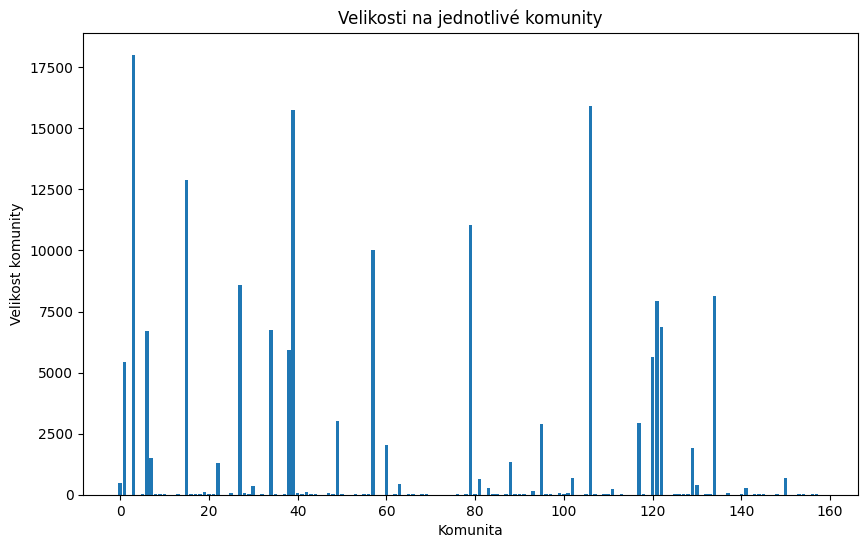

In [79]:
unique_louvain_communities, louvain_community_sizes = louvain_counts

plt.figure(figsize=(10, 6))
plt.bar(x=unique_louvain_communities, height=louvain_community_sizes)
plt.title('Velikosti na jednotlivé komunity')
plt.ylabel('Velikost komunity')
plt.xlabel('Komunita')
plt.show()

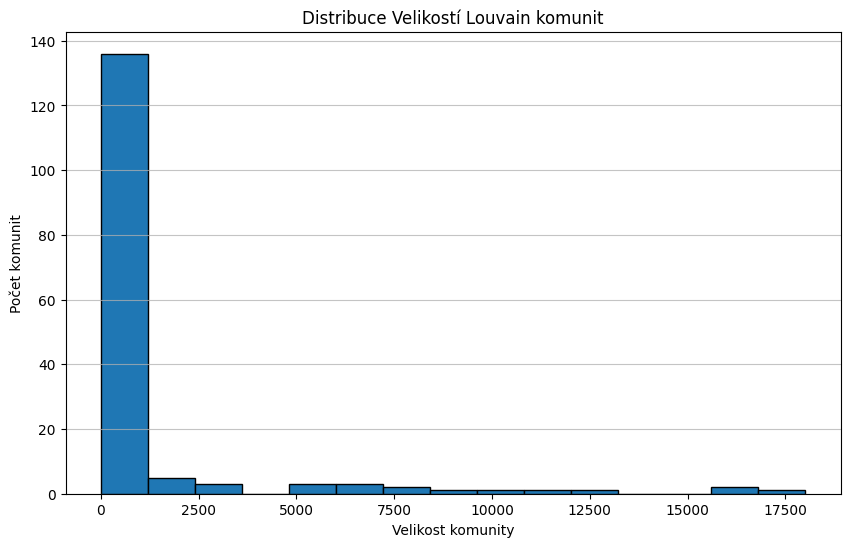

In [76]:
plt.figure(figsize=(10, 6))
plt.hist(louvain_community_sizes, bins=15, edgecolor='black')
plt.title('Distribuce Velikostí Louvain komunit')
plt.xlabel('Velikost komunity')
plt.ylabel('Počet komunit')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [80]:
len(louvain_counts[0])

159

In [84]:
leiden_counts = np.unique_counts(list(leiden_communities_per_node.values()))

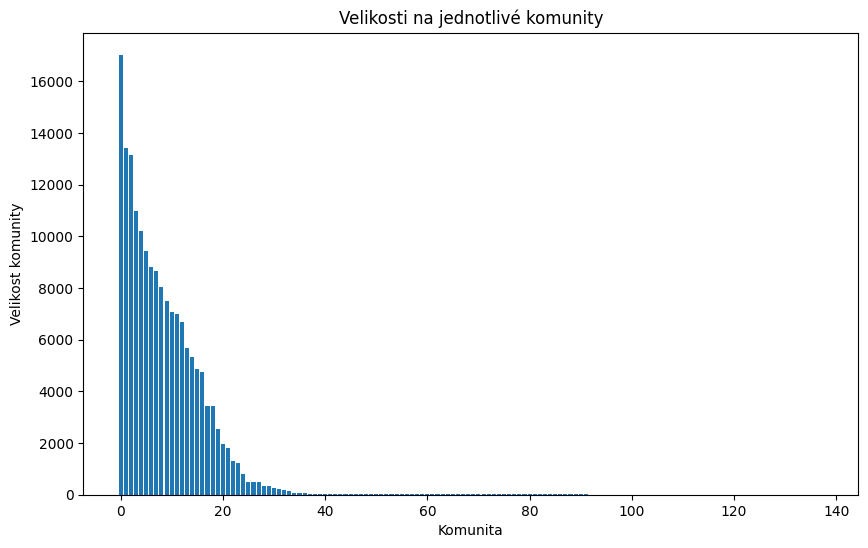

In [85]:
unique_leiden_communities, leiden_community_sizes = leiden_counts

plt.figure(figsize=(10, 6))
plt.bar(x=unique_leiden_communities, height=leiden_community_sizes)
plt.title('Velikosti na jednotlivé komunity')
plt.ylabel('Velikost komunity')
plt.xlabel('Komunita')
plt.show()

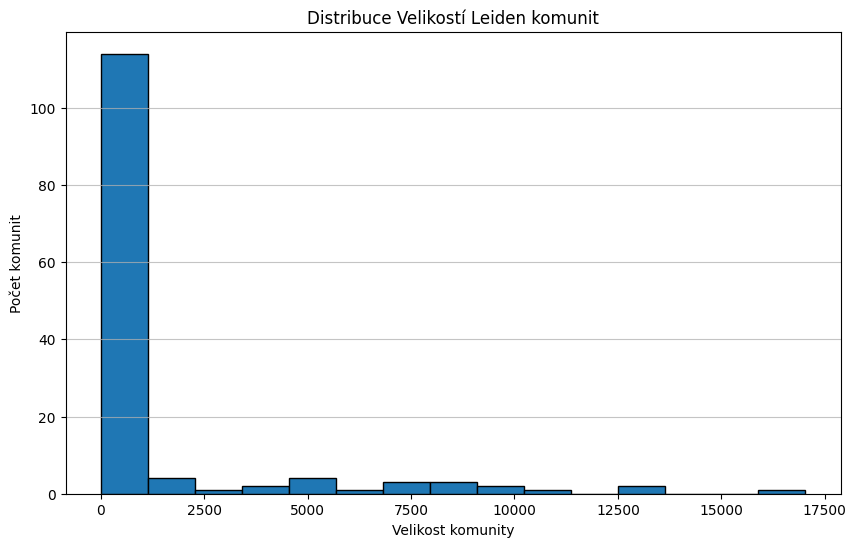

In [86]:
plt.figure(figsize=(10, 6))
plt.hist(leiden_community_sizes, bins=15, edgecolor='black')
plt.title('Distribuce Velikostí Leiden komunit')
plt.xlabel('Velikost komunity')
plt.ylabel('Počet komunit')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [87]:
len(leiden_counts[0])

138